# 07 feature 

## Goal
- Feature scaling이 왜 Gradient Descent를 빠르게/안정적으로 만드는지 코드로 확인한다.
- 아래 3가지 스케일링을 직접 구현한다.
  1) Max scaling
  2) Mean normalization
  3) Z-score normalization (standardization)

## What we will compare
- (Unscaled) 원본 X로 GD 실행
- (Scaled) 스케일링된 X로 GD 실행
- Cost vs Iteration(learning curve) 비교
- "쓸 수 있는 alpha 범위"가 어떻게 달라지는지 비교

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# [집 크기, 방 개수, 층 수, 집 나이]

X_train = np.array([
    [2104, 5, 1, 45],
    [1416, 3, 2, 40],
    [852, 2, 1, 35]
], dtype=float)

# 실제 집 가격 (정답값)
y_train = np.array([460, 232, 178], dtype=float)

print("X_train.shape:", X_train.shape)
print("y_train.shape:", y_train.shape)
print("X_train:\n", X_train)
print("y_train:\n", y_train)

X_train.shape: (3, 4)
y_train.shape: (3,)
X_train:
 [[2.104e+03 5.000e+00 1.000e+00 4.500e+01]
 [1.416e+03 3.000e+00 2.000e+00 4.000e+01]
 [8.520e+02 2.000e+00 1.000e+00 3.500e+01]]
y_train:
 [460. 232. 178.]


## Why scalling?
Gradient Descent에서 각 feature의 값 범위가 크게 다르면,  
- 어떤 w는 아주 크게 업데이트되고
- 어떤 w는 거의 업데이트되지 않으므로  
학습이 느려지거나, alpha를 조금만 크게 해도 발산한다.  

목표: 각 feature의 범위를 비슿하게 만들어서 GD가 덜 지그재그로 움직이게 하기

In [ ]:
def compute_cost(X, y, w, b):
    # 데이터 개수
    m = X.shape[0]
    # w1*x1 + w2*x2 + ... + wn*xn
    # 모델이 예측한 값
    preds = X @ w + b
    cost = (1/(2*m)) * np.sum((preds - y)**2)
    return cost

def compute_gradient(X, y, w, b):
    # m = 데이터 개수
    # n = feature 개수
    m, n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        # 모델이 예측한 값과 실제 정답의 차이
        error = (X[i] @ w + b) - y[i]
        dj_dw += error * X[i]
        dj_db += error
    
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db

def gradient_descent(X, y, w, b, alpha, iterations):
    cost_history = []

    for it in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        # cost 기록
        cost_history.append(compute_cost(X, y, w, b))

    return w, b, np.array(cost_history)


In [12]:
def run_and_plot(X, y, alpha, iterations, title):
    w_init = np.zeros(X.shape[1])
    b_init = 0.0

    w, b, J_hist = gradient_descent(X, y, w_init, b_init, alpha, iterations)

    print(f"[{title}] alpha={alpha}, iterations={iterations}")
    print("final cost:", J_hist[-1])
    print("w:", w)
    print("b:", b)

    plt.figure()
    plt.plot(J_hist)
    plt.xlabel("iteration")
    plt.ylabel("cost J")
    plt.title(title)
    plt.show()

    return w, b, J_hist

# Max Scaling
각 feature column별로 max 나누기

X_scaled = x / max(x)

- 범위를 대략 0 ~ 1 근처로 만든다.
- mean(평균)을 0으로 맞추지는 않는다.

# Max Scaling 구현

In [5]:
def max_scaling(X):
    max_vals = np.max(X, axis=0)
    X_scaled = X / max_vals
    return X_scaled, max_vals

X_max, max_vals = max_scaling(X_train)
print("max_vals:", max_vals)
print("X_max:\n", X_max)

max_vals: [2.104e+03 5.000e+00 2.000e+00 4.500e+01]
X_max:
 [[1.         1.         0.5        1.        ]
 [0.6730038  0.6        1.         0.88888889]
 [0.40494297 0.4        0.5        0.77777778]]


## Mean normalization
각 feature의 평균을 빼서 0 근처로 center 하고,  
range(max-min)로 나눈다.

X_norm = (x - mu) / (max - min)

- 데이터가 0을 중심으로 분호하게 된다. 
- 범위가 대략 -1 ~ 1 근처가 되는 경우가 많다.

# Mean normalization 구현

In [7]:
def mean_normalization(X):
    mu = np.mean(X, axis=0)
    max_vals = np.max(X, axis=0)
    min_vals = np.min(X, axis=0)
    rng = max_vals - min_vals

    X_norm = (X - mu) / rng
    return X_norm, mu, rng

X_mean, mu_vals, range_vals = mean_normalization(X_train)
print("mu:", mu_vals)
print("range:", range_vals)
print("X_mean:\n", X_mean)


mu: [1.45733333e+03 3.33333333e+00 1.33333333e+00 4.00000000e+01]
range: [1.252e+03 3.000e+00 1.000e+00 1.000e+01]
X_mean:
 [[ 0.51650692  0.55555556 -0.33333333  0.5       ]
 [-0.03301384 -0.11111111  0.66666667  0.        ]
 [-0.48349308 -0.44444444 -0.33333333 -0.5       ]]


# Z-score Normalization 표준화
## Z-score normalization (standardization)
가장 많이 쓰는 방법

X_Z = (X - mu) / sigma

- 평균 0
- 표준편차 1
- feature scaling의 기본값으로 많이 사용

# Z-score 구현

In [9]:
def zscore_normalization(X, eps=1e-12):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma = np.where(sigma < eps, 1.0, sigma) # 0 방지
    X_z = (X - mu) / sigma
    return X_z, mu, sigma

X_z, mu_z, sigma_z = zscore_normalization(X_train)
print("mu:", mu_z)
print("sigma:", sigma_z)
print("X_z:\n", X_z)

mu: [1.45733333e+03 3.33333333e+00 1.33333333e+00 4.00000000e+01]
sigma: [5.11961804e+02 1.24721913e+00 4.71404521e-01 4.08248290e+00]
X_z:
 [[ 1.26311506  1.33630621 -0.70710678  1.22474487]
 [-0.08073519 -0.26726124  1.41421356  0.        ]
 [-1.18237987 -1.06904497 -0.70710678 -1.22474487]]


# 실험 1: Unscaled vs Scaled

## Experiment 1 같은 alpha로 돌려본다
- Unscaled는 alpha를 크게 주면 발산/불안정할 가능성이 높다.
- Scaled는 더 큰 alpha도 안정적으로 내려갈 가능성이 높다.

먼저 안전한 alpha로 시작해 cost가 잘 내려가는지 비교한다.

[Unscaled (alpha=1e-7)] alpha=1e-07, iterations=200
final cost: 696.6474171907353
w: [ 0.20223982  0.00059704 -0.00029614  0.00221594]
b: 2.6977125537604796e-05


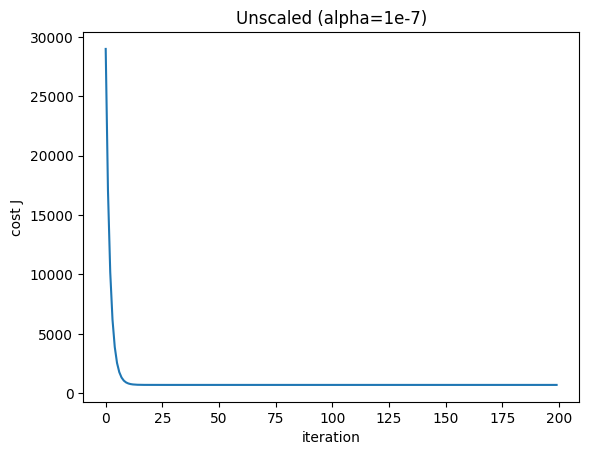

[Z-score scaled (alpha=1e-1)] alpha=0.1, iterations=200
final cost: 2.1048064636121118e-14
w: [ 38.05161505  41.54327451 -30.98894654  36.34177447]
b: 289.9999997954027


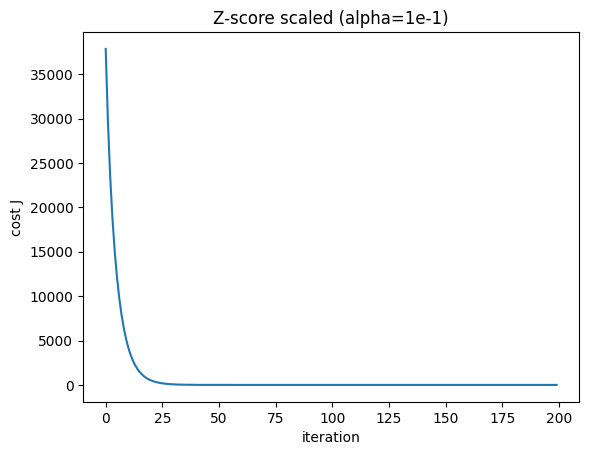

(array([ 38.05161505,  41.54327451, -30.98894654,  36.34177447]),
 np.float64(289.9999997954027),
 array([3.78404552e+04, 2.95359129e+04, 2.33762876e+04, 1.86655766e+04,
        1.49867744e+04, 1.20742000e+04, 9.74806762e+03, 7.88014888e+03,
        6.37512603e+03, 5.15999081e+03, 4.17766966e+03, 3.38294672e+03,
        2.73969539e+03, 2.21889806e+03, 1.79717091e+03, 1.45563236e+03,
        1.17901756e+03, 9.54976395e+02, 7.73512449e+02, 6.26532180e+02,
        5.07481616e+02, 4.11052951e+02, 3.32947340e+02, 2.69682975e+02,
        2.18439734e+02, 1.76933403e+02, 1.43313821e+02, 1.16082395e+02,
        9.40252879e+01, 7.61593111e+01, 6.16880952e+01, 4.99665922e+01,
        4.04723214e+01, 3.27820807e+01, 2.65530815e+01, 2.15076695e+01,
        1.74209484e+01, 1.41107548e+01, 1.14295389e+01, 9.25778709e+00,
        7.49869482e+00, 6.07385168e+00, 4.91974620e+00, 3.98493487e+00,
        3.22774910e+00, 2.61443786e+00, 2.11766320e+00, 1.71528176e+00,
        1.38935766e+00, 1.12536309e+00

In [16]:
iterations = 200
run_and_plot(X_train, y_train, alpha=1e-7, iterations=iterations, title="Unscaled (alpha=1e-7)")
run_and_plot(X_z, y_train, alpha=1e-1, iterations=iterations, title="Z-score scaled (alpha=1e-1)")

# 실험 2: alpha sweep 여러 alpha를 자동 비교

## Experiment 2 alpha를 여러 개 시도해서 learning curve 비교
- 여러 alpha를 짧게 돌려보고
- cost가 빠르고 안정적으로 감소하는 값을 고른다.

# alpha sweep 함수

In [18]:
def alpha_sweep(X, y, alphas, iterations, label_prefix):
    results = []
    for a in alphas:
        w_init = np.zeros(X.shape[1])
        b_init = 0.0
        w, b, J_hist = gradient_descent(X, y, w_init, b_init, a, iterations)
        results.append((a, J_hist))
        print(f"{label_prefix} alpha={a} final cost={J_hist[-1]}")
    return results

def plot_sweep(results, title):
    plt.figure()
    for a, J_hist in results:
        plt.plot(J_hist, label=f"a={a}")
    plt.xlabel("iteration")
    plt.ylabel("cost J")
    plt.title(title)
    plt.legend()
    plt.show()

Unscaled alpha=1e-08 final cost=700.1331107554399
Unscaled alpha=3e-08 final cost=696.9502097199852
Unscaled alpha=1e-07 final cost=696.6474171907353
Unscaled alpha=3e-07 final cost=695.7863764034747
Unscaled alpha=1e-06 final cost=3.783192328422338e+61


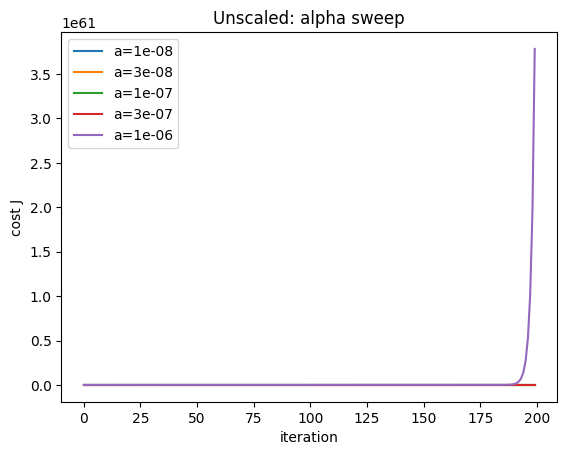

Z-score alpha=0.001 final cost=30563.131712110102
Z-score alpha=0.003 final cost=12940.240412671601
Z-score alpha=0.01 final cost=760.9419208222467
Z-score alpha=0.03 final cost=0.21662043186171442
Z-score alpha=0.1 final cost=2.1048064636121118e-14


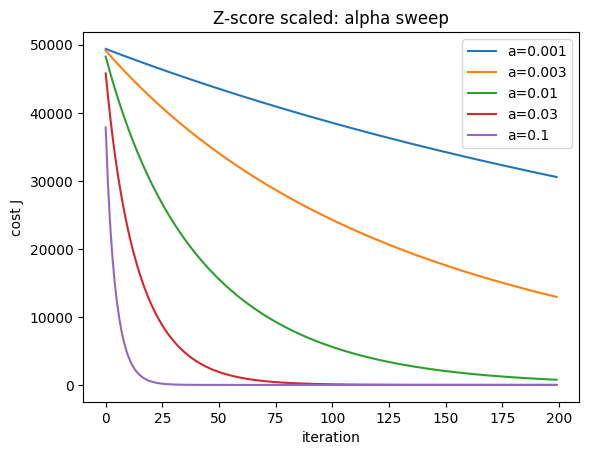

In [19]:
iterations = 200

alphas_unscaled = [1e-8, 3e-8, 1e-7, 3e-7, 1e-6]
res_unscaled = alpha_sweep(X_train, y_train, alphas_unscaled, iterations, "Unscaled")
plot_sweep(res_unscaled, "Unscaled: alpha sweep")

alphas_z = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
res_z = alpha_sweep(X_z, y_train, alphas_z, iterations, "Z-score")
plot_sweep(res_z, "Z-score scaled: alpha sweep")

## What to look for (결과 해석)
Cost J가 iteration마다 꾸준히 감소하는가?
- 가끔 올라가면: alpha가 너무 크거나, 코드 버그 가능성

어느 alpha가 가장 빨리 내려가면서도 안정적인가?
- 발산 직전보다 약간 작은 alpha가 좋은 선택

Scaling 전/후로 alpha 범위가 어떻게 달라지는가?
- Unscaled: 아주 작은 alpha만 안정적일 가능성이 큼
- Scaled: 훨씬 큰 alpha도 안정적으로 작동